# Generic Exploratory Data Analysis (EDA) Template
### JPMorgan Corporate Finance & Market Data Project

**Instructions:** 
1. Change the `FILE_PATH` variable in the box below to point to your dataset (e.g. your Bloomberg spin-off CSV or WRDS output).
2. The notebook automatically detects if the file is a `.csv` or `.parquet` format and processes it accordingly.
3. Run all cells to generate structured data quality checks, statistical summaries, and exploratory visualizations.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting styles to look clean and professional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ==========================================================
# CONFIGURATION: CHANGE THIS TO YOUR FILE PATH
# Supports: 'your_file.csv' or 'your_file.parquet'
# ==========================================================


FILE_PATH2 = "data/clean/cleaned_primary_spinoffs.csv"
FILE_PATH = "data/raw/crsp_index_returns.parquet"

def load_data(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found at: {path}. Please check the path and try again.")
    ext = os.path.splitext(path)[-1].lower()
    if ext == '.csv':
        print(f"Loading CSV file from: {path}")
        return pd.read_csv(path)
    elif ext == '.parquet':
        print(f"Loading Parquet file from: {path}")
        return pd.read_parquet(path)
    else:
        raise ValueError("Unsupported file format! Please use a .csv or .parquet file.")

# Load the dataframe
df = load_data(FILE_PATH)
df2 = load_data(FILE_PATH2)


Loading Parquet file from: data/raw/sp500_constituents_with_permno.parquet
Data successfully loaded! Shape: 360 rows, 15 columns.


## 1. High-Level Structural Audit
Inspect data types, column schemas, and sample the first few entries.

In [2]:
print("--- DATAFRAME INFO ---")
print(df.info())

print("\n--- FIRST 10 ROWS ---")
df.head(10)

--- DATAFRAME INFO ---
<class 'pandas.DataFrame'>
Index: 360 entries, 1 to 435
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   gvkey         360 non-null    string        
 1   start_date    360 non-null    datetime64[ns]
 2   end_date      360 non-null    datetime64[ns]
 3   still_active  360 non-null    bool          
 4   company_name  360 non-null    string        
 5   ticker        360 non-null    string        
 6   cusip         360 non-null    string        
 7   cik           360 non-null    string        
 8   sic           360 non-null    string        
 9   naics         360 non-null    string        
 10  permno        360 non-null    Float64       
 11  linktype      360 non-null    string        
 12  linkprim      360 non-null    string        
 13  linkdt        360 non-null    datetime64[ns]
 14  linkenddt     360 non-null    datetime64[ns]
dtypes: Float64(1), bool(1), datetime6

,gvkey,start_date,end_date,still_active,company_name,ticker,cusip,cik,sic,naics,permno,linktype,linkprim,linkdt,linkenddt
1,004640,1996-03-08,2026-06-17,True,FIFTH THIRD BANCORP,FITB,316773100,0000035527,6020,522110,34746.0,LU,P,1980-01-31,2026-06-17
3,003221,1996-04-23,2026-06-17,True,AON PLC,AON,G0403H108,0000315293,6411,524210,61735.0,LC,P,1980-06-02,2026-06-17
4,010530,1997-01-02,2026-06-17,True,THERMO FISHER SCIENTIFIC INC,TMO,883556102,0000097745,3826,334516,62092.0,LC,P,1972-12-14,2026-06-17
5,023809,1997-01-02,2026-06-17,True,AUTOZONE INC,AZO,053332102,0000866787,5531,441330,76605.0,LU,P,1991-04-02,2026-06-17
6,012540,1997-05-06,2026-06-17,True,ADOBE INC,ADBE,00724F101,0000796343,7370,518210,75510.0,LC,P,1986-08-13,2026-06-17
7,002751,1997-05-27,2026-06-17,True,CARDINAL HEALTH INC,CAH,14149Y108,0000721371,5122,424210,21371.0,LC,P,1983-08-04,2026-06-17
8,013988,1997-06-02,2026-06-17,True,SCHWAB (CHARLES) CORP,SCHW,808513105,0000316709,6282,523940,75186.0,LC,P,1987-09-22,2026-06-17
9,004423,1997-06-19,2026-06-17,True,EQUIFAX INC,EFX,294429105,0000033185,7323,561450,52476.0,LU,P,1971-05-11,2026-06-17
10,001678,1997-07-28,2026-06-17,True,APA CORP,APA,03743Q108,0001841666,1311,2111,39490.0,LC,P,1964-01-31,2026-06-17
12,013341,1997-08-04,2026-06-17,True,PROGRESSIVE CORP-OHIO,PGR,743315103,0000080661,6331,524126,64390.0,LU,P,1979-01-31,2026-06-17


## 2. Data Quality & Completeness Audit
Check for structural gaps, missing values, and duplicate rows.

In [3]:
print("--- MISSING VALUES AUDIT ---")
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_table = pd.concat([missing_count, missing_pct], axis=1, keys=['Missing Count', 'Percentage (%)'])
missing_table = missing_table[missing_table['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if missing_table.empty:
    print("Clean data! No missing values detected.")
else:
    print(missing_table)
    
print("\n--- DUPLICATE ROW CHECK ---")
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count} ({duplicate_count/len(df)*100:.2f}%)")

--- MISSING VALUES AUDIT ---
Clean data! No missing values detected.

--- DUPLICATE ROW CHECK ---
Number of duplicate rows: 0 (0.00%)


## 3. Statistical Summaries
Segment columns into numerical vs. categorical variables and evaluate basic mathematical metrics.

In [4]:
# Identify numerical vs categorical splits
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"Detected {len(num_cols)} numerical columns and {len(cat_cols)} categorical columns.")

if num_cols:
    print("\n--- NUMERICAL COLUMNS STATS ---")
    display(df[num_cols].describe().T)

if cat_cols:
    print("\n--- CATEGORICAL COLUMNS STATS ---")
    display(df[cat_cols].describe().T)

Detected 1 numerical columns and 1 categorical columns.

--- NUMERICAL COLUMNS STATS ---


,count,mean,std,min,25%,50%,75%,max
permno,360.0,59685.405556,30894.931195,10138.0,23352.0,76661.5,86972.0,93436.0



--- CATEGORICAL COLUMNS STATS ---


,count,unique,top,freq
still_active,360,1,True,360


## 4. Distributions & Outliers
Automated visualization of value splits and outlying elements across the top numerical attributes.

Visualizing distributions for: ['permno']


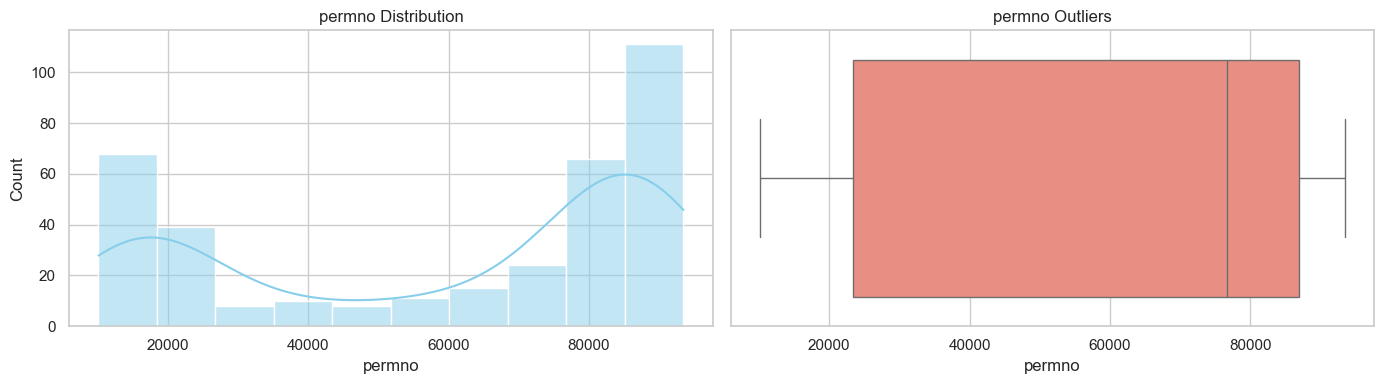

In [5]:
# Automatically plots distributions for up to the first 6 numerical columns to avoid cluttering memory
cols_to_plot = num_cols[:6]

if cols_to_plot:
    print(f"Visualizing distributions for: {cols_to_plot}")
    fig, axes = plt.subplots(len(cols_to_plot), 2, figsize=(14, 4 * len(cols_to_plot)))
    if len(cols_to_plot) == 1:
        axes = np.expand_dims(axes, axis=0)
        
    for i, col in enumerate(cols_to_plot):
        # Histogram/KDE
        sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
        axes[i, 0].set_title(f'{col} Distribution')
        
        # Boxplot for Outliers
        sns.boxplot(x=df[col], ax=axes[i, 1], color='salmon')
        axes[i, 1].set_title(f'{col} Outliers')
        
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found to plot.")

## 5. Correlation Matrix
Evaluate co-movements and multi-collinearity trends across the loaded features.

In [6]:
if len(num_cols) > 1:
    print("--- CORRELATION MATRIX ---")
    corr = df[num_cols].corr()
    
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True, linewidths=.5)
    plt.title("Numerical Features Correlation Heatmap")
    plt.show()
else:
    print("Not enough numerical columns to compute a correlation matrix.")

Not enough numerical columns to compute a correlation matrix.
